# 00 Data Exploration — NFHS-5 (Stage 1)

This notebook performs initial EDA for the district-level NFHS-5 dataset used in BarrierLens Stage 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'NFHS5_Women.csv'
print('Project root:', PROJECT_ROOT)
print('Raw path:', RAW_PATH)

Project root: B:\PBCS\Major Project\BarrierLens_MP_G25_P48
Raw path: B:\PBCS\Major Project\BarrierLens_MP_G25_P48\data\raw\NFHS5_Women.csv


In [2]:
df = pd.read_csv(RAW_PATH)
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('First 10 columns:')
print(df.columns[:10].tolist())
print('\nDtypes (top 20):')
print(df.dtypes.head(20))

df.head(3)

Shape: (706, 109)
First 10 columns:
['District Names', 'State/UT', 'Number of Households surveyed', 'Number of Women age 15-49 years interviewed', 'Number of Men age 15-54 years interviewed', 'Female population age 6 years and above who ever attended school (%)', 'Population below age 15 years (%)', 'Sex ratio of the total population (females per 1,000 males)', 'Sex ratio at birth for children born in the last five years (females per 1,000 males)', 'Children under age 5 years whose birth was registered with the civil authority (%)']

Dtypes (top 20):
District Names                                                                              object
State/UT                                                                                    object
Number of Households surveyed                                                                int64
Number of Women age 15-49 years interviewed                                                  int64
Number of Men age 15-54 years interviewed      

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.0,23.0,973,927,98.0,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.7,19.8,950,844,100.0,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.7,21.0,967,935,96.5,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8


In [3]:
missing_by_col = df.isnull().sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]

print('Columns with missing values:', missing_by_col.shape[0])
missing_by_col.head(20)

Columns with missing values: 0


Series([], dtype: int64)

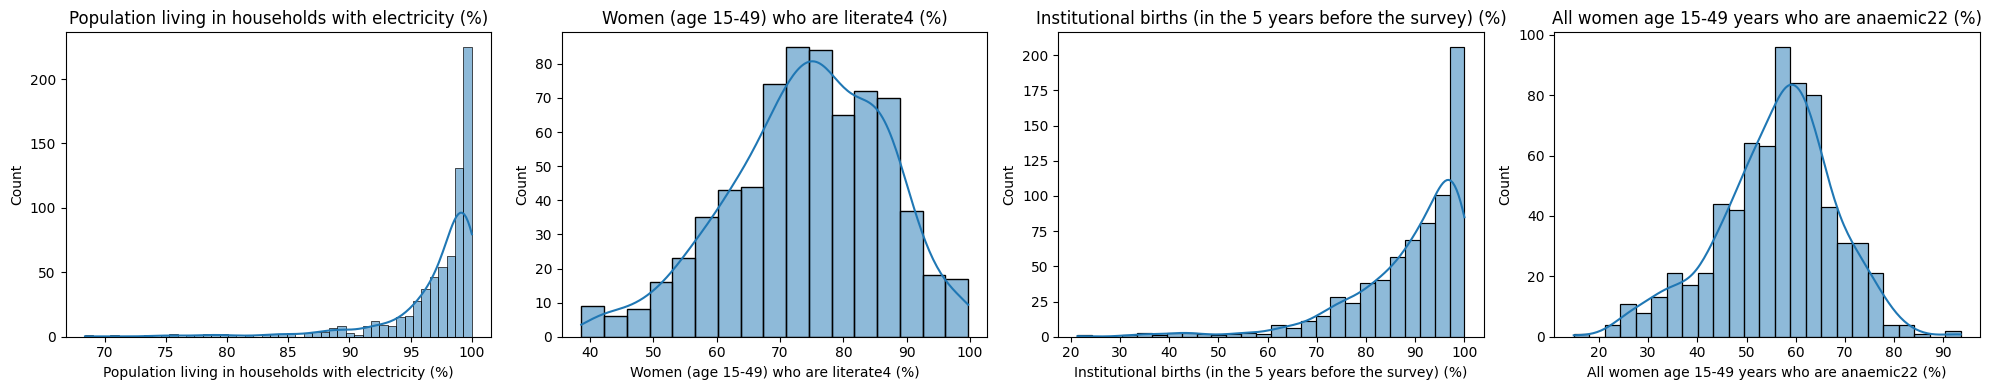

In [4]:
sample_cols = [
    'Population living in households with electricity (%)',
    'Women (age 15-49) who are literate4 (%)',
    'Institutional births (in the 5 years before the survey) (%)',
    'All women age 15-49 years who are anaemic22 (%)',
]

plot_cols = [c for c in sample_cols if c in df.columns]
num = len(plot_cols)

fig, axes = plt.subplots(1, num, figsize=(5 * num, 4))
if num == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

C:\Users\pbcsh\AppData\Local\Temp\ipykernel_17208\1097346484.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


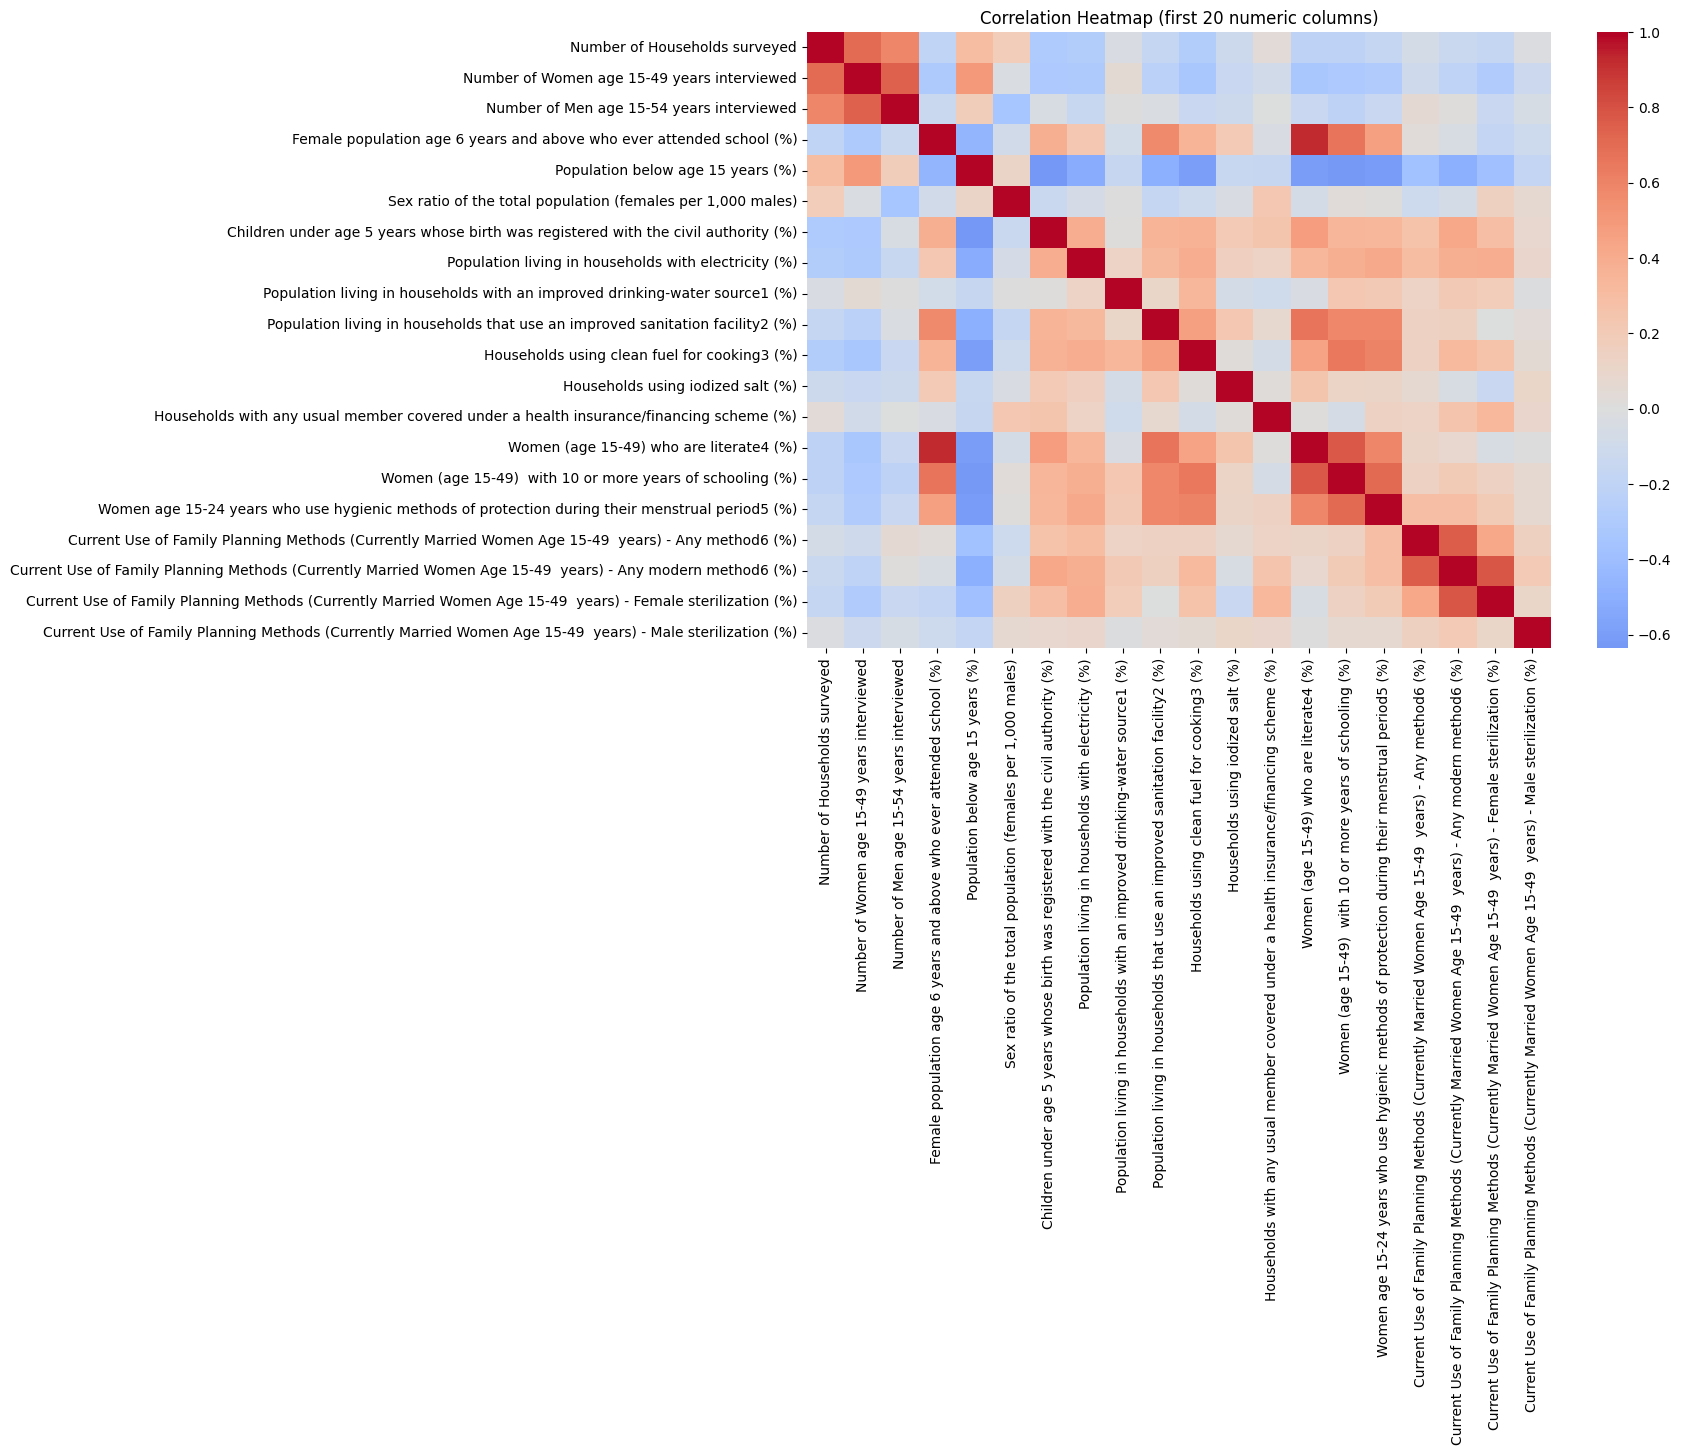

In [5]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Keep the view readable by focusing on the first 20 numeric columns.
heatmap_cols = numeric_df.columns[:20]
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df[heatmap_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (first 20 numeric columns)')
plt.tight_layout()
plt.show()